### This the visualization of the results that we generated through running backtest on strategies

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy as sa
from sqlalchemy import text
from dotenv import load_dotenv

load_dotenv()

def get_db_engine():
    db_host = os.getenv("DB_HOST")
    db_port = os.getenv("DB_PORT")
    db_name = os.getenv("DB_NAME")
    db_user = os.getenv("DB_USER")
    db_password = os.getenv("DB_PASSWORD")
    connection_string = f"postgresql+psycopg://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
    return sa.create_engine(connection_string)

engine = get_db_engine()

In [2]:
combos = pd.read_sql(
    text("""
        SELECT strategy, env, COUNT(*) AS n_rows,
               MIN(snapshot_date) AS first_date, MAX(snapshot_date) AS last_date
        FROM account_snapshot
        GROUP BY strategy, env
        ORDER BY strategy, env;
    """),
    engine
)
combos

,strategy,env,n_rows,first_date,last_date
0,Mean_Z_Score_BB1,backtest,365,2025-02-06,2026-08-03


In [ ]:
def load_account_snapshot(engine, strategy: str, env: str = "backtest") -> pd.DataFrame:
    """
    Loads the account_snapshot time series for one (strategy, env) pair,
    sorted by date, with snapshot_date set as a proper DatetimeIndex.
    """
    query = text("""
        SELECT snapshot_date, cash, positions_value, total_equity
        FROM account_snapshot
        WHERE strategy = :strategy AND env = :env
        ORDER BY snapshot_date;
    """)
    df = pd.read_sql(query, engine, params={"strategy": strategy, "env": env})

    if df.empty:
        raise ValueError(f"No rows for strategy={strategy!r}, env={env!r} — check spelling against the combos table above.")

    df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
    df = df.set_index("snapshot_date")
    return df

equity_df = load_account_snapshot(engine, strategy="Mean_Z_Score_BB1", env="backtest")
equity_df.he ad()

,cash,positions_value,total_equity
snapshot_date,,,
2025-02-06,496641.001209,3355.00,499996.001209
2025-02-07,492543.853673,7447.27,499991.123673
2025-02-10,495276.836153,4439.12,499715.956153
2025-02-11,479998.345330,19550.03,499548.375330
2025-02-12,471526.228598,27954.71,499480.938598


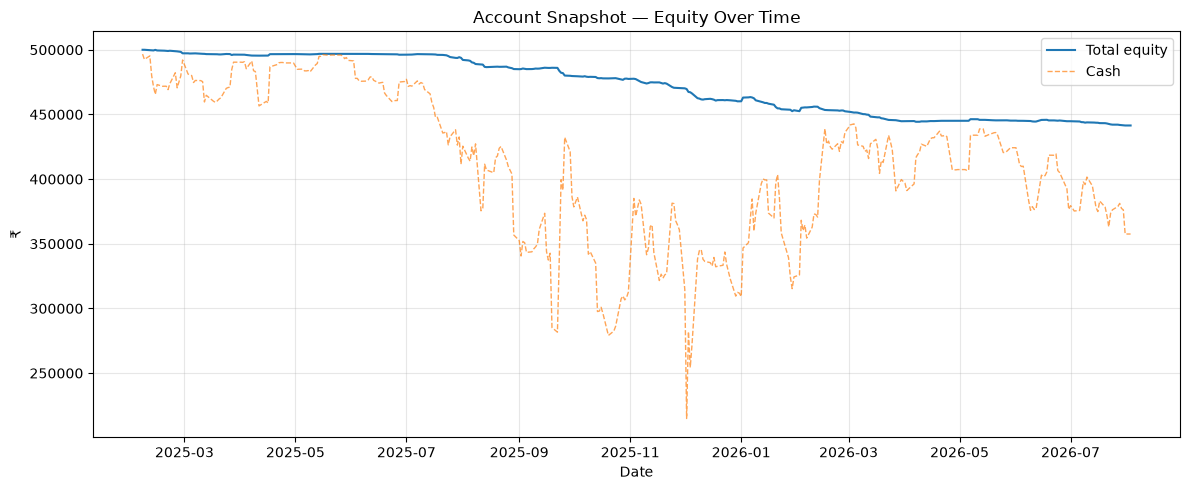

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(equity_df.index, equity_df["total_equity"], label="Total equity", linewidth=1.5)
ax.plot(equity_df.index, equity_df["cash"], label="Cash", linewidth=1, linestyle="--", alpha=0.7)

ax.set_title("Account Snapshot — Equity Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("₹")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()